In [69]:
%pip install pandas numpy matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [70]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for better data viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")


Libraries imported successfully!


In [71]:
# Load the CSV file
df = pd.read_csv('car_prices_extended_eda.csv')

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()


Dataset shape: (472325, 32)

Column names:
['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'seller', 'mmr', 'sellingprice', 'saledate', 'price_diff', 'car_age', 'mileage_per_year', 'sale_year', 'sale_month', 'sale_day', 'seller_category', 'condition_category', 'sale_day_of_week', 'sale_day_name', 'sale_hour', 'is_weekend', 'sale_month_name', 'price_gap_pct', 'gap_category', 'is_luxury']

First few rows:


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,price_diff,car_age,mileage_per_year,sale_year,sale_month,sale_day,seller_category,condition_category,sale_day_of_week,sale_day_name,sale_hour,is_weekend,sale_month_name,price_gap_pct,gap_category,is_luxury
0,2015,Kia,Sorento,LX,suv,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 12:30:00,1000.0,0,16639.0,2014,12,16,Manufacturer,Poor,1,Tuesday,12,0,December,4.878049,Small Gain (0% to 5%),0
1,2015,Kia,Sorento,LX,suv,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 12:30:00,700.0,0,9393.0,2014,12,16,Manufacturer,Poor,1,Tuesday,12,0,December,3.365385,Small Gain (0% to 5%),0
2,2014,BMW,3 Series,328i SULEV,sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-15 04:30:00,-1900.0,1,1331.0,2015,1,14,Financial,Good,3,Thursday,4,0,January,-5.956113,Moderate Loss (-10% to -5%),1
3,2015,Volvo,S60,T5,sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-29 04:30:00,250.0,0,14282.0,2015,1,28,Fleet/Other,Good,3,Thursday,4,0,January,0.909091,Small Gain (0% to 5%),1
4,2014,BMW,6 Series Gran Coupe,650i,sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 12:30:00,1000.0,0,2641.0,2014,12,18,Financial,Good,3,Thursday,12,0,December,1.515152,Small Gain (0% to 5%),1


In [72]:
# Get dataset information
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("\nBasic Statistics:")
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472325 entries, 0 to 472324
Data columns (total 32 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   year                472325 non-null  int64  
 1   make                472325 non-null  object 
 2   model               472325 non-null  object 
 3   trim                472325 non-null  object 
 4   body                472325 non-null  object 
 5   transmission        472325 non-null  object 
 6   vin                 472325 non-null  object 
 7   state               472325 non-null  object 
 8   condition           472325 non-null  float64
 9   odometer            472325 non-null  float64
 10  color               472325 non-null  object 
 11  interior            472325 non-null  object 
 12  seller              472325 non-null  object 
 13  mmr                 472325 non-null  float64
 14  sellingprice        472325 non-null  float64
 15  saledate            

In [73]:
# Check for missing values
print("Missing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Percentage of missing values: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.2f}%")


Missing values per column:
Series([], dtype: int64)

Total missing values: 0
Percentage of missing values: 0.00%


In [74]:
# Check data types
print("Data types:")
print(df.dtypes)


Data types:
year                    int64
make                   object
model                  object
trim                   object
body                   object
transmission           object
vin                    object
state                  object
condition             float64
odometer              float64
color                  object
interior               object
seller                 object
mmr                   float64
sellingprice          float64
saledate               object
price_diff            float64
car_age                 int64
mileage_per_year      float64
sale_year               int64
sale_month              int64
sale_day                int64
seller_category        object
condition_category     object
sale_day_of_week        int64
sale_day_name          object
sale_hour               int64
is_weekend              int64
sale_month_name        object
price_gap_pct         float64
gap_category           object
is_luxury               int64
dtype: object


In [75]:
# Install additional ML libraries
%pip install scikit-learn xgboost



Note: you may need to restart the kernel to use updated packages.


In [76]:
# Import ML libraries
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Try to import XGBoost (optional - may fail if OpenMP is not installed)
xgb_available = False
try:
    import xgboost as xgb
    xgb_available = True
    print("✓ XGBoost imported successfully!")
except Exception as e:
    print(f"⚠ XGBoost not available: {str(e)[:100]}...")
    print("   Continuing without XGBoost.")
    print("   To fix: Run 'brew install libomp' in terminal, then restart kernel.")

print("\nML libraries imported successfully!")

✓ XGBoost imported successfully!

ML libraries imported successfully!


In [77]:
# Prepare data for modeling
# Select features (excluding target and non-predictive columns)
# IMPORTANT: Exclude features that cause data leakage (derived from target variable)

# Features to exclude:
# - vin, saledate: non-predictive identifiers
# - sellingprice: target variable
# - sale_day_name, sale_month_name: redundant (we have sale_day, sale_month)
# - mmr: Manheim Market Report (market price estimate - too close to target, causes leakage)
# - price_diff: sellingprice - mmr (directly derived from target!)
# - price_gap_pct: percentage gap (derived from target!)
# - gap_category: category based on price gap (derived from target!)

exclude_cols = [
    'vin', 'saledate', 'sellingprice',  # Target and identifiers
    'sale_day_name', 'sale_month_name',  # Redundant columns
    'mmr',  # Market price estimate (causes data leakage)
    'price_diff',  # Derived from target (sellingprice - mmr)
    'price_gap_pct',  # Derived from target
    'gap_category'  # Derived from target
]

# Select features
feature_cols = [col for col in df.columns if col not in exclude_cols]
X = df[feature_cols].copy()
y = df['sellingprice'].copy()

print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")
print(f"\nExcluded features (to prevent data leakage): {[col for col in exclude_cols if col in df.columns]}")
print(f"\nTarget variable statistics:")
print(y.describe())


Number of features: 23
Features: ['year', 'make', 'model', 'trim', 'body', 'transmission', 'state', 'condition', 'odometer', 'color', 'interior', 'seller', 'car_age', 'mileage_per_year', 'sale_year', 'sale_month', 'sale_day', 'seller_category', 'condition_category', 'sale_day_of_week', 'sale_hour', 'is_weekend', 'is_luxury']

Excluded features (to prevent data leakage): ['vin', 'saledate', 'sellingprice', 'sale_day_name', 'sale_month_name', 'mmr', 'price_diff', 'price_gap_pct', 'gap_category']

Target variable statistics:
count    472325.000000
mean      13690.512058
std        9613.033738
min           1.000000
25%        7200.000000
50%       12200.000000
75%       18200.000000
max      230000.000000
Name: sellingprice, dtype: float64


In [78]:
# Separate numerical and categorical features
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"\nCategorical features ({len(categorical_cols)}): {categorical_cols}")



Numerical features (12): ['year', 'condition', 'odometer', 'car_age', 'mileage_per_year', 'sale_year', 'sale_month', 'sale_day', 'sale_day_of_week', 'sale_hour', 'is_weekend', 'is_luxury']

Categorical features (11): ['make', 'model', 'trim', 'body', 'transmission', 'state', 'color', 'interior', 'seller', 'seller_category', 'condition_category']


In [79]:
# Encode categorical variables
X_encoded = X.copy()

# Use LabelEncoder for categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

print("Categorical variables encoded successfully!")
print(f"Final feature matrix shape: {X_encoded.shape}")


Categorical variables encoded successfully!
Final feature matrix shape: (472325, 23)


In [80]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]:,} samples")
print(f"Test set size: {X_test.shape[0]:,} samples")
print(f"Number of features: {X_train.shape[1]}")



Training set size: 377,860 samples
Test set size: 94,465 samples
Number of features: 23


In [86]:
# Note: Tree-based models (Random Forest, XGBoost) don't require feature scaling
# Scaling is only needed for linear models, which we're not using
print("Feature scaling not needed for tree-based models (Random Forest & XGBoost)")


Feature scaling not needed for tree-based models (Random Forest & XGBoost)


In [89]:
# Hyperparameter tuning for Random Forest to improve R² score (FAST VERSION)
print("=" * 80)
print("HYPERPARAMETER TUNING FOR RANDOM FOREST (FAST VERSION)")
print("=" * 80)

# Use a sample of data for faster hyperparameter tuning
print(f"\nOriginal training set size: {X_train.shape[0]:,} samples")
sample_size = 50000  # Use 50K samples for tuning (much faster)
X_train_sample = X_train.sample(n=min(sample_size, len(X_train)), random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

print(f"Using sample size: {len(X_train_sample):,} samples for hyperparameter tuning")
print("(Full dataset will be used for final model training)")

# Define parameter grid for Random Forest (reduced for speed)
rf_param_grid = {
    'n_estimators': [300, 500, 800],  # Reduced from 5 to 3 options
    'max_depth': [20, 25, 30, None],  # Reduced options
    'min_samples_split': [2, 5],  # Reduced options
    'min_samples_leaf': [1, 2],  # Reduced options
    'max_features': [0.5, 0.7, 'sqrt']  # Reduced options
}

# Create base Random Forest model
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Use RandomizedSearchCV with fewer iterations and 2-fold CV for speed
print("\nStarting hyperparameter search (optimized for speed)...")
print("This should take 5-10 minutes instead of 45+ minutes")
rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=10,  # Reduced from 30 to 10 iterations
    cv=2,  # Reduced from 3 to 2 folds (2x faster)
    scoring='r2',  # Optimize for R² score
    n_jobs=-1,  # Use all CPU cores
    random_state=42,
    verbose=1
)

# Fit the random search on sample data
rf_random_search.fit(X_train_sample, y_train_sample)

# Get best parameters
best_rf_params = rf_random_search.best_params_
best_rf_score = rf_random_search.best_score_


print(f"\n✓ Hyperparameter tuning completed!")
print(f"Best R² Score (CV): {best_rf_score:.4f}")
print(f"\nBest Parameters:")
for param, value in best_rf_params.items():
    print(f"  {param}: {value}")

# Initialize models with optimized parameters
models = {
    'Random Forest (Optimized)': RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1),
    'Random Forest (Default)': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# Add XGBoost only if available
if xgb_available:
    models['XGBoost'] = xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    print("\n✓ XGBoost model included")
else:
    print("\n⚠ XGBoost model skipped (not available)")

print(f"\nModels initialized!")
print(f"Total models to compare: {len(models)}")
print(f"Models: {list(models.keys())}")

HYPERPARAMETER TUNING FOR RANDOM FOREST (FAST VERSION)

Original training set size: 377,860 samples
Using sample size: 50,000 samples for hyperparameter tuning
(Full dataset will be used for final model training)

Starting hyperparameter search (optimized for speed)...
This should take 5-10 minutes instead of 45+ minutes
Fitting 2 folds for each of 10 candidates, totalling 20 fits

✓ Hyperparameter tuning completed!
Best R² Score (CV): 0.8563

Best Parameters:
  n_estimators: 300
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: 0.7
  max_depth: 20

✓ XGBoost model included

Models initialized!
Total models to compare: 3
Models: ['Random Forest (Optimized)', 'Random Forest (Default)', 'XGBoost']


In [90]:
# Train and evaluate Random Forest and XGBoost
results = {}

print("Training models...")
print("=" * 80)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Tree-based models don't need scaled data
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    }
    
    print(f"  R² Score: {r2:.4f}")
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  MAE: ${mae:,.2f}")

print("\n" + "=" * 80)
print("All models trained successfully!")


Training models...

Training Random Forest (Optimized)...
  R² Score: 0.9534
  RMSE: $2,057.80
  MAE: $1,207.75

Training Random Forest (Default)...
  R² Score: 0.9528
  RMSE: $2,072.01
  MAE: $1,198.45

Training XGBoost...
  R² Score: 0.9307
  RMSE: $2,509.31
  MAE: $1,551.50

All models trained successfully!


In [91]:
# Create a comparison DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R²', ascending=False)

print("Model Performance Comparison:")
print("=" * 80)
print(results_df.round(4))
print("\n" + "=" * 80)
print(f"\n🏆 BEST MODEL: {results_df.index[0]}")
print(f"   R² Score: {results_df.iloc[0]['R²']:.4f}")
print(f"   RMSE: ${results_df.iloc[0]['RMSE']:,.2f}")
print(f"   MAE: ${results_df.iloc[0]['MAE']:,.2f}")


Model Performance Comparison:
                                    MSE       RMSE        MAE      R²
Random Forest (Optimized)  4.234558e+06  2057.8042  1207.7489  0.9534
Random Forest (Default)    4.293228e+06  2072.0106  1198.4547  0.9528
XGBoost                    6.296616e+06  2509.3059  1551.5049  0.9307


🏆 BEST MODEL: Random Forest (Optimized)
   R² Score: 0.9534
   RMSE: $2,057.80
   MAE: $1,207.75


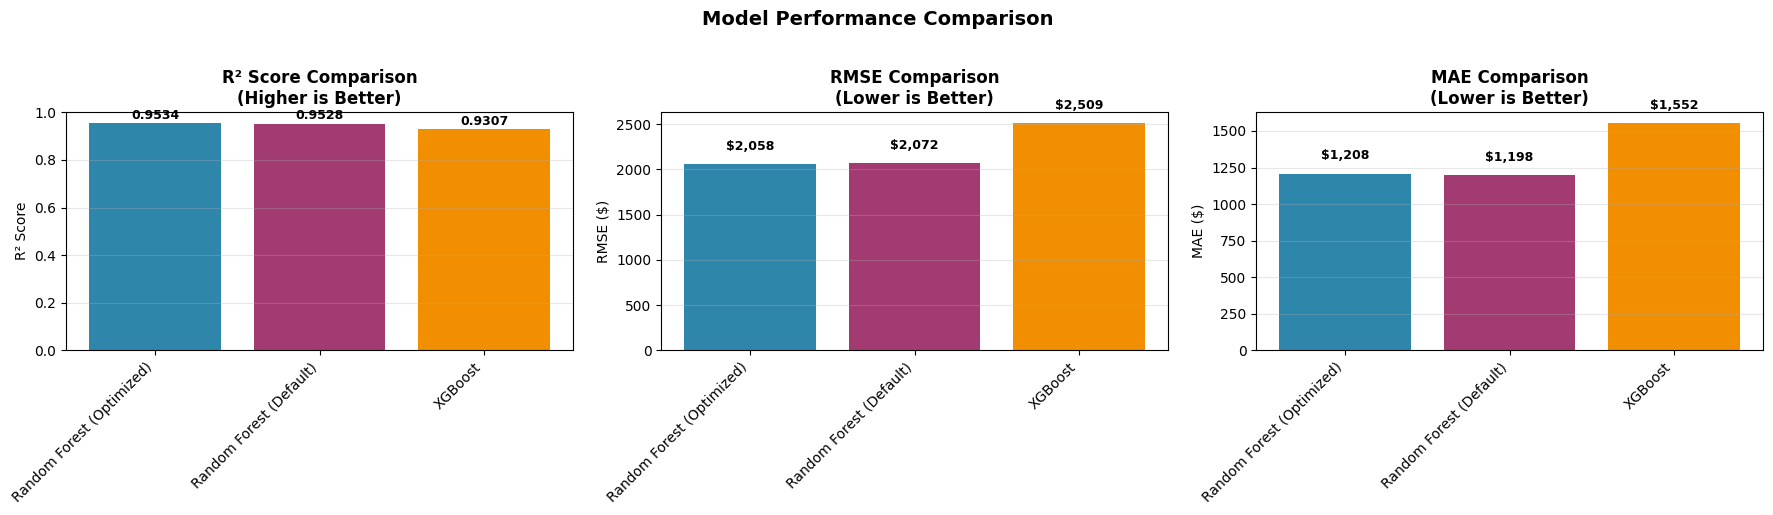

In [92]:
# Visualize model comparison
n_models = len(results_df)
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E'][:n_models]

fig, axes = plt.subplots(1, 3, figsize=(6*n_models if n_models <= 3 else 18, 5))

# R² Score comparison
axes[0].bar(range(n_models), results_df['R²'], color=colors)
axes[0].set_xticks(range(n_models))
axes[0].set_xticklabels(results_df.index, rotation=45, ha='right')
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score Comparison\n(Higher is Better)', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['R²']):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# RMSE comparison
axes[1].bar(range(n_models), results_df['RMSE'], color=colors)
axes[1].set_xticks(range(n_models))
axes[1].set_xticklabels(results_df.index, rotation=45, ha='right')
axes[1].set_ylabel('RMSE ($)')
axes[1].set_title('RMSE Comparison\n(Lower is Better)', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['RMSE']):
    axes[1].text(i, v + max(results_df['RMSE']) * 0.05, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# MAE comparison
axes[2].bar(range(n_models), results_df['MAE'], color=colors)
axes[2].set_xticks(range(n_models))
axes[2].set_xticklabels(results_df.index, rotation=45, ha='right')
axes[2].set_ylabel('MAE ($)')
axes[2].set_title('MAE Comparison\n(Lower is Better)', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['MAE']):
    axes[2].text(i, v + max(results_df['MAE']) * 0.05, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



In [93]:
# Get predictions from all models for comparison
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)

# Create comparison DataFrame
prediction_comparison = pd.DataFrame({
    'Actual': y_test.values
})

# Add predictions from all models
for name, pred in predictions.items():
    prediction_comparison[name] = pred

# Show sample predictions
print("Sample Predictions Comparison:")
print("=" * 80)
print(prediction_comparison.head(20))
print("\n" + "=" * 80)

# Get the best model
best_model_name = results_df.index[0]
best_model = models[best_model_name]



Sample Predictions Comparison:
     Actual  Random Forest (Optimized)  Random Forest (Default)       XGBoost
0    3500.0                4257.425229                  4260.00   6112.517578
1   19300.0               23166.071364                 23274.00  21803.800781
2   25000.0               25350.155554                 26034.00  24760.960938
3   10400.0               10152.114163                 10299.02  10869.925781
4    9400.0                8910.643453                  9222.00   9161.951172
5   16100.0               16249.500827                 16028.00  17242.306641
6   16400.0               16367.686159                 16430.00  16401.048828
7   23500.0               23562.145707                 23515.00  24429.201172
8    6500.0                6881.517365                  6482.50   5601.504883
9   15400.0               14611.354293                 14386.00  16289.876953
10  18100.0               18968.383874                 19242.00  18062.904297
11   2000.0                1920.9

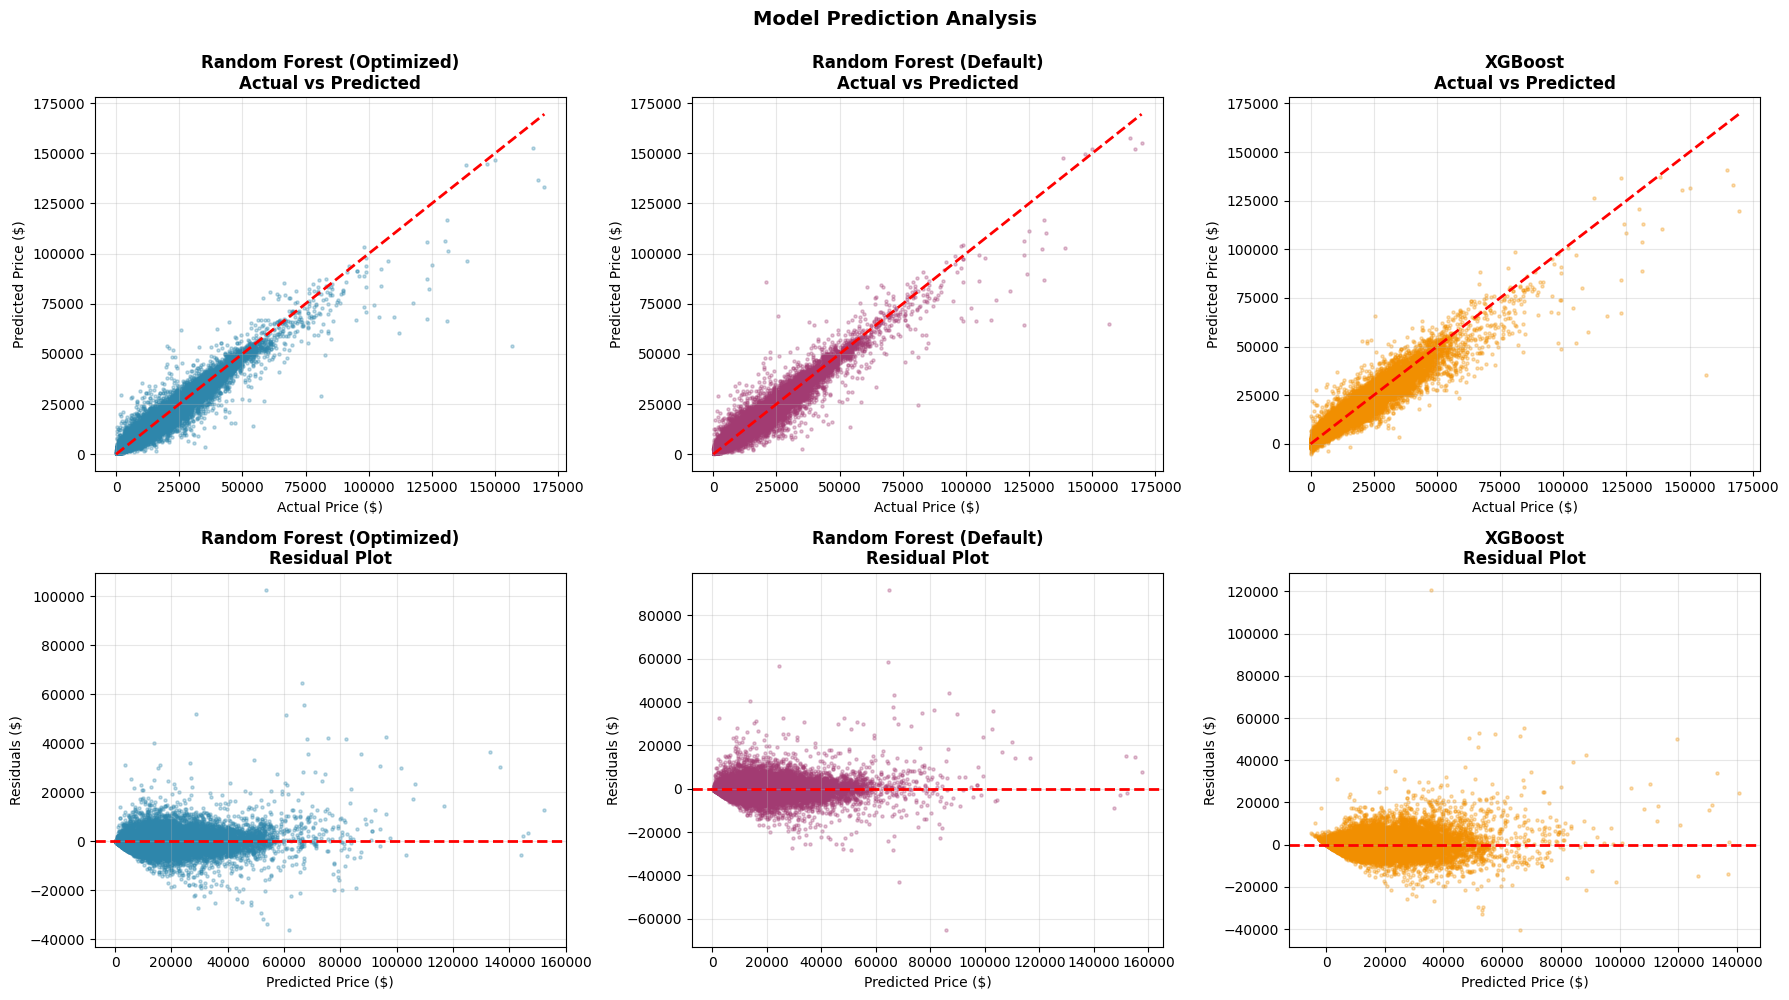

In [94]:
# Visualize predictions vs actual values for all models
n_models = len(predictions)
# Define enough colors for all models (supports up to 5 models)
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E'][:n_models]

fig, axes = plt.subplots(2, n_models, figsize=(6*n_models, 10))

model_idx = 0
for name, y_pred in predictions.items():
    # Scatter plot: Actual vs Predicted
    axes[0, model_idx].scatter(y_test, y_pred, alpha=0.3, s=5, color=colors[model_idx])
    axes[0, model_idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0, model_idx].set_xlabel('Actual Price ($)')
    axes[0, model_idx].set_ylabel('Predicted Price ($)')
    axes[0, model_idx].set_title(f'{name}\nActual vs Predicted', fontweight='bold')
    axes[0, model_idx].grid(alpha=0.3)
    
    # Residual plot
    residuals = y_test - y_pred
    axes[1, model_idx].scatter(y_pred, residuals, alpha=0.3, s=5, color=colors[model_idx])
    axes[1, model_idx].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[1, model_idx].set_xlabel('Predicted Price ($)')
    axes[1, model_idx].set_ylabel('Residuals ($)')
    axes[1, model_idx].set_title(f'{name}\nResidual Plot', fontweight='bold')
    axes[1, model_idx].grid(alpha=0.3)
    
    model_idx += 1

plt.suptitle('Model Prediction Analysis', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()




Top 15 Most Important Features (Random Forest (Optimized)):
           feature  importance
          odometer    0.261149
              year    0.137161
         is_luxury    0.118621
              body    0.116721
             model    0.104127
              trim    0.077138
              make    0.065506
           car_age    0.048275
         condition    0.020980
  mileage_per_year    0.012741
            seller    0.009216
condition_category    0.003993
             state    0.003783
          sale_day    0.003753
          interior    0.003400

Top 15 Most Important Features (Random Forest (Default)):
         feature  importance
        odometer    0.334081
            body    0.123569
       is_luxury    0.121672
            year    0.112023
           model    0.100183
            trim    0.079367
            make    0.055296
       condition    0.020866
mileage_per_year    0.011751
          seller    0.008431
         car_age    0.006771
        sale_day    0.004360
       

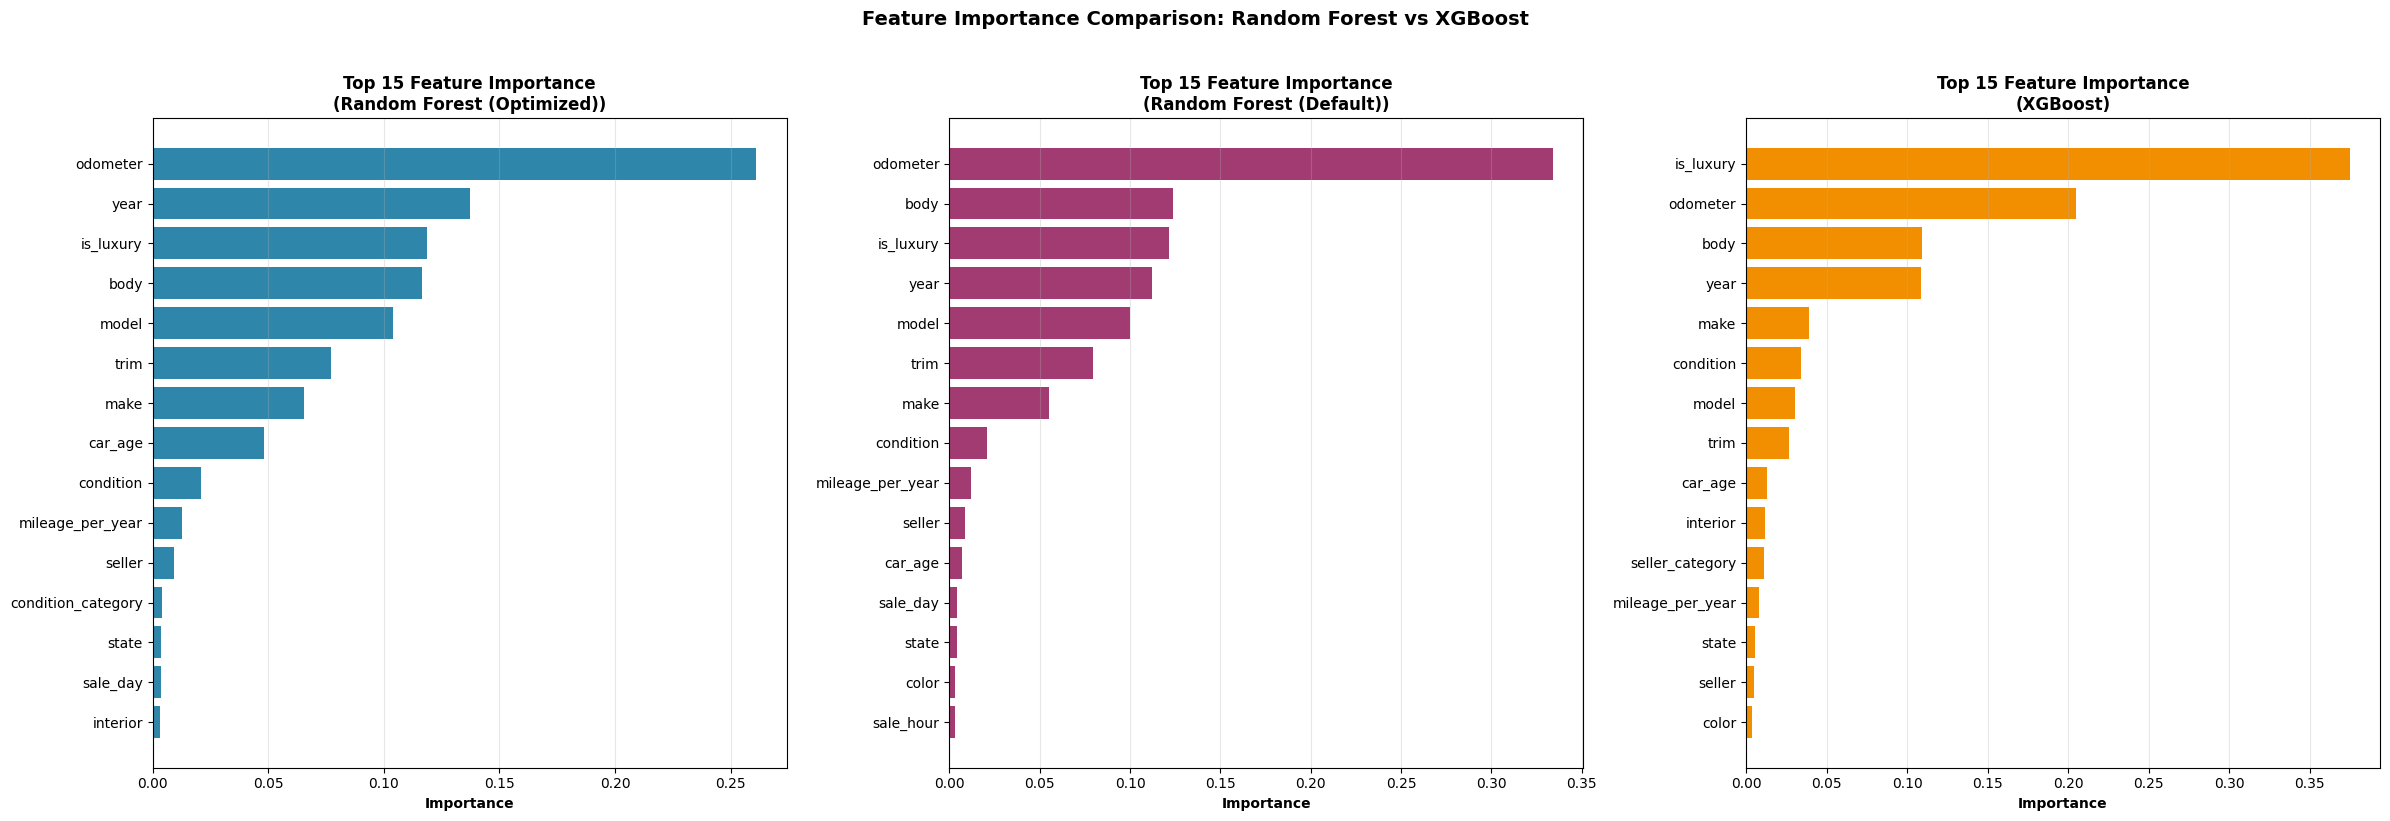

In [95]:
# Feature importance comparison for both models
feature_importance_dict = {}

for name, model in models.items():
    if hasattr(model, 'feature_importances_'):
        # Retrain to get feature importance
        model.fit(X_train, y_train)
        feature_importance_dict[name] = pd.DataFrame({
            'feature': feature_cols,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)

# Display top features for each model
for name, feature_importance in feature_importance_dict.items():
    print(f"\nTop 15 Most Important Features ({name}):")
    print("=" * 80)
    print(feature_importance.head(15).to_string(index=False))

# Visualize feature importance side by side
if len(feature_importance_dict) > 0:
    fig, axes = plt.subplots(1, len(feature_importance_dict), figsize=(8*len(feature_importance_dict), 8))
    
    if len(feature_importance_dict) == 1:
        axes = [axes]
    
    for idx, (name, feature_importance) in enumerate(feature_importance_dict.items()):
        top_features = feature_importance.head(15)
        axes[idx].barh(range(len(top_features)), top_features['importance'], 
                       color=['#2E86AB', '#A23B72', '#F18F01'][idx % 3])
        axes[idx].set_yticks(range(len(top_features)))
        axes[idx].set_yticklabels(top_features['feature'])
        axes[idx].set_xlabel('Importance', fontweight='bold')
        axes[idx].set_title(f'Top 15 Feature Importance\n({name})', fontsize=12, fontweight='bold')
        axes[idx].grid(axis='x', alpha=0.3)
        axes[idx].invert_yaxis()
    
    plt.suptitle('Feature Importance Comparison: Random Forest vs XGBoost', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No feature importance available for the models.")
